In [1]:
pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.



  NVDA: 2513 rows
  AAPL: 2513 rows
  SPY: 2513 rows
  CBA.AX: 2529 rows
  BHP.AX: 2529 rows
  CSL.AX: 2529 rows

  MA CROSSOVER STRATEGY — FULL COMPARISON TABLE
                  B&H Total Return %  Strat Total Return %  Strat Annual Return %  B&H Sharpe  Strat Sharpe  B&H Max DD %  Strat Max DD %  Win Rate %
Ticker MA Pair                                                                                                                                       
AAPL   MA10/30                947.19                388.04                  17.24        0.92          0.88        -38.52          -30.79       53.43
       MA100/200              947.19                282.40                  14.40        0.92          0.56        -38.52          -39.63       53.44
       MA20/50                947.19                312.89                  15.29        0.92          0.76        -38.52          -29.09       52.99
       MA25/60                947.19                304.88                  15.06      

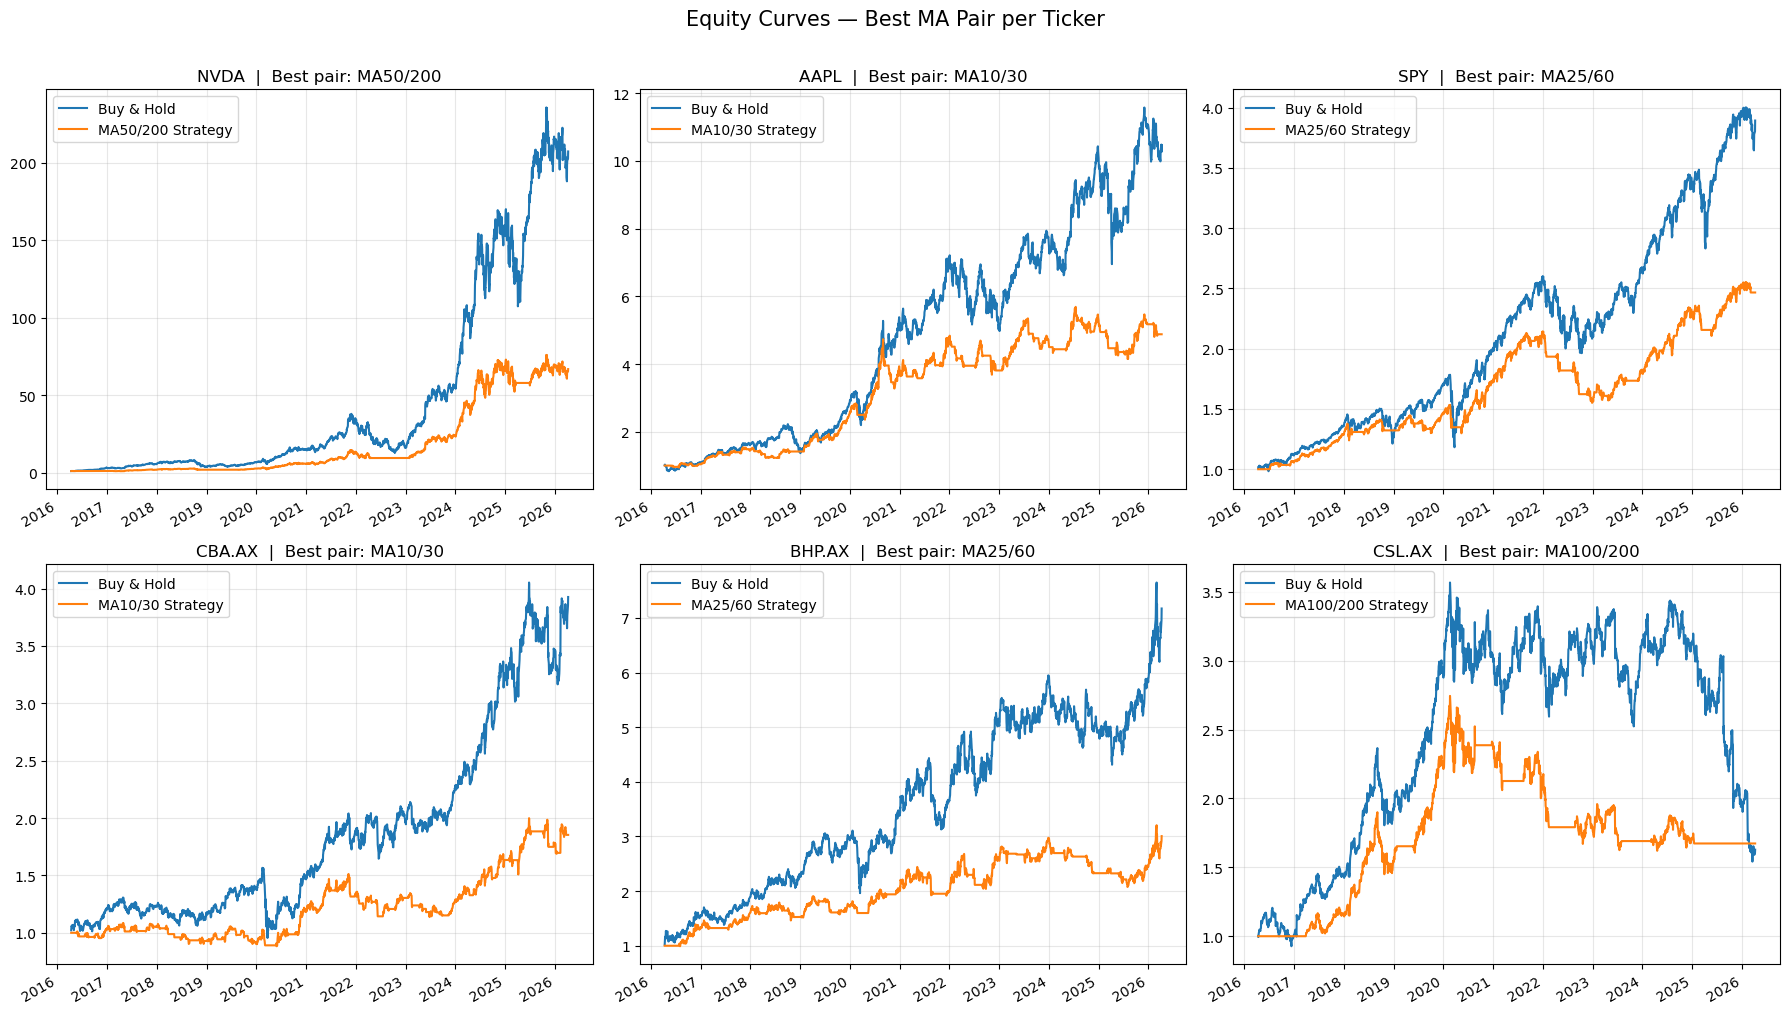


Chart saved as ma_best_equity_curves.png


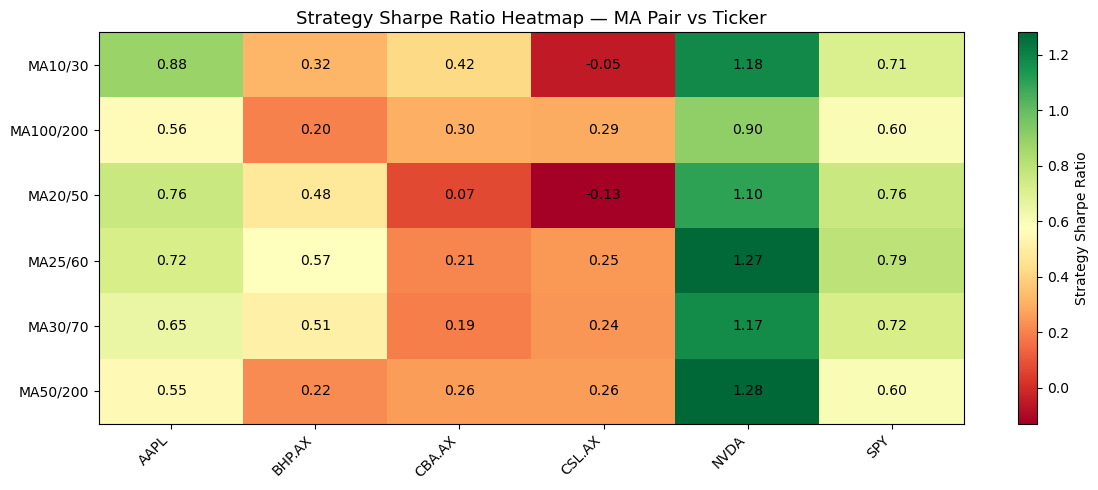

Heatmap saved as ma_sharpe_heatmap.png


In [5]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

# ── Configuration ──────────────────────────────────────────────────────────────
endDate   = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365 * 10)

stocks = ["NVDA", "AAPL", "SPY", "CBA.AX", "BHP.AX", "CSL.AX"]

# MA pairs to test: (fast window, slow window)
ma_pairs = [(10, 30), (20, 50), (25, 60), (30, 70), (50, 200), (100, 200)]

# 252 trading days/year for stocks; ASX and US both use 252 for comparison
PERIODS_PER_YEAR = 252


# ── Helper: run a single MA crossover backtest ─────────────────────────────────
# Logic: buy when fast MA crosses above slow MA, exit when it crosses below
# Fast MA reacts quicker to price changes; slow MA shows the longer trend
def run_backtest(price_series, fast, slow):
    df = pd.DataFrame({"price": price_series})
    df[f"MA{fast}"] = df["price"].rolling(window=fast).mean()
    df[f"MA{slow}"] = df["price"].rolling(window=slow).mean()

    # 1 when fast MA is above slow MA, else 0
    df["signal"]   = (df[f"MA{fast}"] > df[f"MA{slow}"]).astype(int)
    df["position"] = df["signal"].shift(1)          # act the day after signal

    df["log_returns"]          = np.log(df["price"] / df["price"].shift(1))
    df["strategy_log_returns"] = df["position"] * df["log_returns"]

    df["cum_market"]   = np.exp(df["log_returns"].cumsum())
    df["cum_strategy"] = np.exp(df["strategy_log_returns"].cumsum())
    return df


# ── Helper: max drawdown ───────────────────────────────────────────────────────
def max_drawdown(cum_series):
    running_max = cum_series.cummax()
    drawdown    = (cum_series - running_max) / running_max
    return drawdown.min()


# ── Helper: compute all metrics for one backtest run ──────────────────────────
def get_metrics(df):
    market_lr   = df["log_returns"].dropna()
    strategy_lr = df["strategy_log_returns"].dropna()

    total_mkt   = df["cum_market"].dropna().iloc[-1]   - 1
    total_strat = df["cum_strategy"].dropna().iloc[-1] - 1

    ann_mkt     = np.exp(market_lr.mean()   * PERIODS_PER_YEAR) - 1
    ann_strat   = np.exp(strategy_lr.mean() * PERIODS_PER_YEAR) - 1

    vol_mkt     = market_lr.std()   * np.sqrt(PERIODS_PER_YEAR)
    vol_strat   = strategy_lr.std() * np.sqrt(PERIODS_PER_YEAR)

    sharpe_mkt   = ann_mkt   / vol_mkt   if vol_mkt   != 0 else np.nan
    sharpe_strat = ann_strat / vol_strat if vol_strat != 0 else np.nan

    mdd_mkt   = max_drawdown(df["cum_market"].dropna())
    mdd_strat = max_drawdown(df["cum_strategy"].dropna())

    winning_days = (strategy_lr > 0).sum()
    total_days   = (strategy_lr != 0).sum()
    win_rate     = winning_days / total_days if total_days > 0 else np.nan

    return {
        "B&H Total Return %":    round(total_mkt   * 100, 2),
        "Strat Total Return %":  round(total_strat * 100, 2),
        "Strat Annual Return %": round(ann_strat   * 100, 2),
        "B&H Sharpe":            round(sharpe_mkt,   2),
        "Strat Sharpe":          round(sharpe_strat, 2),
        "B&H Max DD %":          round(mdd_mkt   * 100, 2),
        "Strat Max DD %":        round(mdd_strat * 100, 2),
        "Win Rate %":            round(win_rate   * 100, 2),
    }


# ── Step 1: Download price data (once per ticker) ─────────────────────────────
print("Downloading price data...\n")
price_data = {}
for stock in stocks:
    raw = yf.download(stock, start=startDate, end=endDate, auto_adjust=True, progress=False)
    price_data[stock] = raw["Close"].squeeze()
    print(f"  {stock}: {len(raw)} rows")


# ── Step 2: Run all MA pair x stock combinations ───────────────────────────────
all_results = []

for fast, slow in ma_pairs:
    for stock in stocks:
        df      = run_backtest(price_data[stock], fast, slow)
        metrics = get_metrics(df)
        metrics["Ticker"]  = stock
        metrics["MA Pair"] = f"MA{fast}/{slow}"
        all_results.append(metrics)


# ── Step 3: Build the comparison table ────────────────────────────────────────
results_df = (
    pd.DataFrame(all_results)
    .set_index(["Ticker", "MA Pair"])
    .sort_index()
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("\n" + "=" * 100)
print("  MA CROSSOVER STRATEGY — FULL COMPARISON TABLE")
print("=" * 100)
print(results_df.to_string())


# ── Step 4: Best MA pair per stock (by Strategy Sharpe) ───────────────────────
reset    = results_df.reset_index()
best_idx = reset.groupby("Ticker")["Strat Sharpe"].idxmax()
best     = reset.loc[best_idx, ["Ticker", "MA Pair", "Strat Sharpe",
                                  "Strat Total Return %", "Strat Max DD %", "Win Rate %"]]
best     = best.set_index("Ticker")

print("\n" + "=" * 100)
print("  BEST MA PAIR PER TICKER  (ranked by Strategy Sharpe Ratio)")
print("=" * 100)
print(best.to_string())


# ── Step 5: Equity curves — best MA pair per stock ────────────────────────────
best_pairs = best["MA Pair"].to_dict()

n_stocks = len(stocks)
cols = 3
rows = (n_stocks + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, stock in enumerate(stocks):
    ax = axes[i]
    fast_str, slow_str = best_pairs[stock].replace("MA", "").split("/")
    fast, slow = int(fast_str), int(slow_str)

    df = run_backtest(price_data[stock], fast, slow)
    df[["cum_market", "cum_strategy"]].plot(ax=ax)

    ax.set_title(f"{stock}  |  Best pair: {best_pairs[stock]}", fontsize=12)
    ax.set_xlabel("")
    ax.legend(["Buy & Hold", f"MA{fast}/{slow} Strategy"])
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Equity Curves — Best MA Pair per Ticker", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("ma_best_equity_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved as ma_best_equity_curves.png")


# ── Step 6: Strategy Sharpe heatmap (MA pair vs Ticker) ───────────────────────
sharpe_pivot = reset.pivot(index="MA Pair", columns="Ticker", values="Strat Sharpe")

fig2, ax2 = plt.subplots(figsize=(12, 5))
im = ax2.imshow(sharpe_pivot.values, cmap="RdYlGn", aspect="auto")
plt.colorbar(im, ax=ax2, label="Strategy Sharpe Ratio")

ax2.set_xticks(range(len(sharpe_pivot.columns)))
ax2.set_xticklabels(sharpe_pivot.columns, rotation=45, ha="right")
ax2.set_yticks(range(len(sharpe_pivot.index)))
ax2.set_yticklabels(sharpe_pivot.index)
ax2.set_title("Strategy Sharpe Ratio Heatmap — MA Pair vs Ticker", fontsize=13)

for row_i in range(len(sharpe_pivot.index)):
    for col_j in range(len(sharpe_pivot.columns)):
        val = sharpe_pivot.values[row_i, col_j]
        ax2.text(col_j, row_i, f"{val:.2f}", ha="center", va="center",
                 fontsize=10, color="black")

plt.tight_layout()
plt.savefig("ma_sharpe_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved as ma_sharpe_heatmap.png")



  NVDA — All MA Pairs Compared
           B&H Total Return %  Strat Total Return %  Strat Annual Return %  B&H Sharpe  Strat Sharpe  B&H Max DD %  Strat Max DD %  Win Rate %
MA Pair                                                                                                                                       
MA10/30               20632.7               3802.11                  44.42        1.43          1.18        -66.34          -45.61       54.57
MA100/200             20632.7               2485.52                  38.58        1.43          0.90        -66.34          -52.92       54.16
MA20/50               20632.7               3217.53                  42.09        1.43          1.10        -66.34          -63.60       53.76
MA25/60               20632.7               5334.71                  49.30        1.43          1.27        -66.34          -59.02       54.11
MA30/70               20632.7               4297.35                  46.16        1.43          1.17        -6

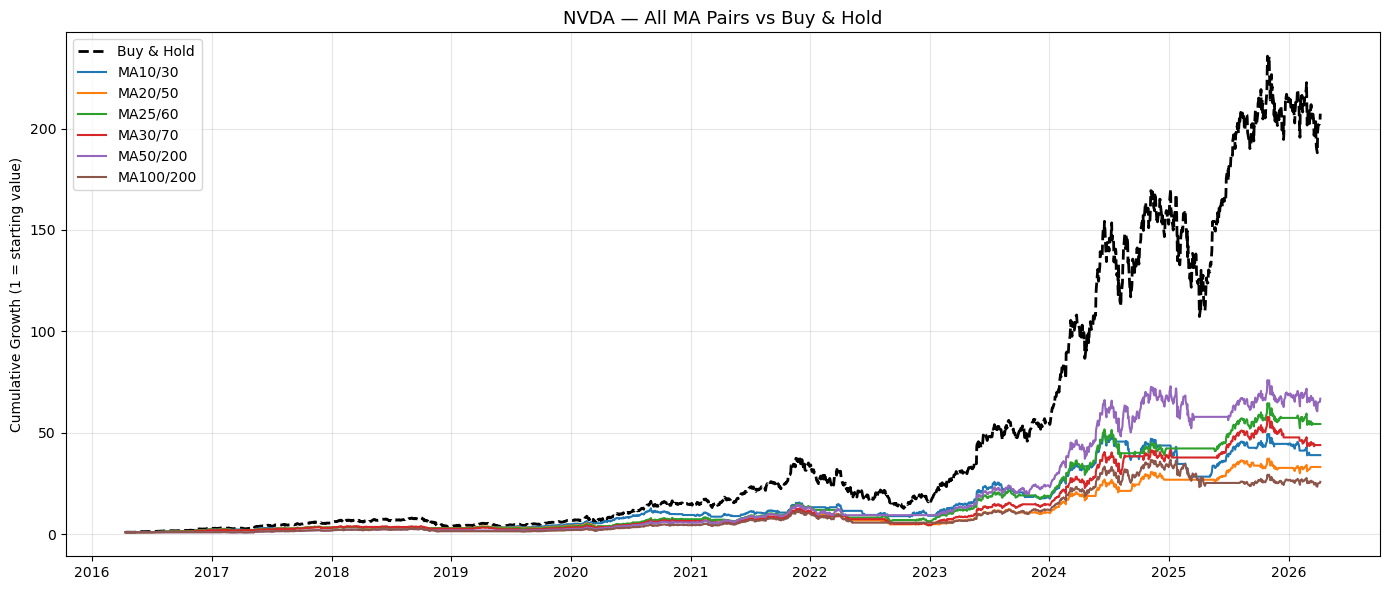

Saved: ma_all_pairs_NVDA.png



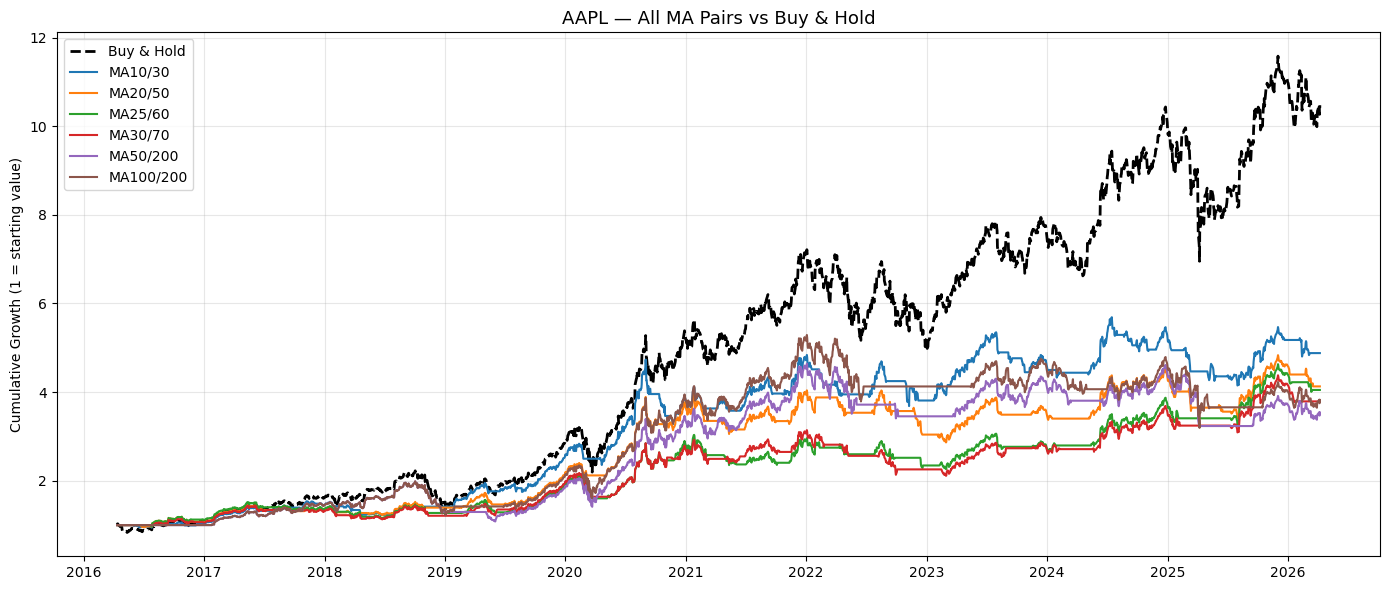

Saved: ma_all_pairs_AAPL.png



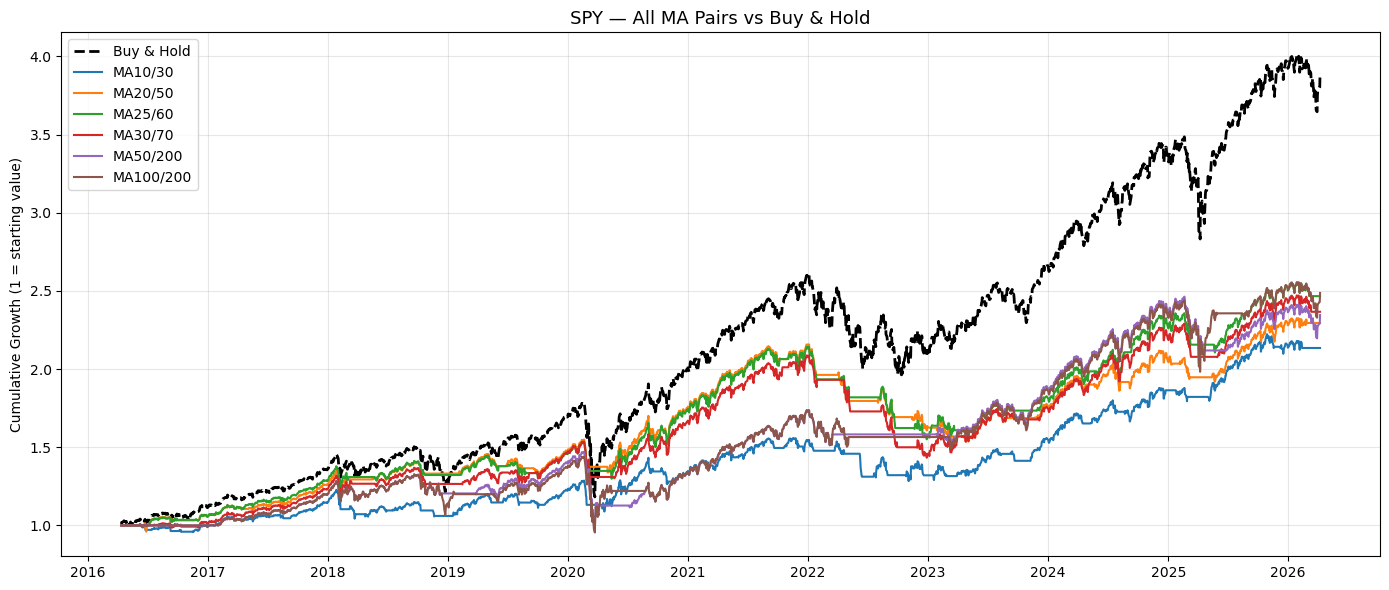

Saved: ma_all_pairs_SPY.png



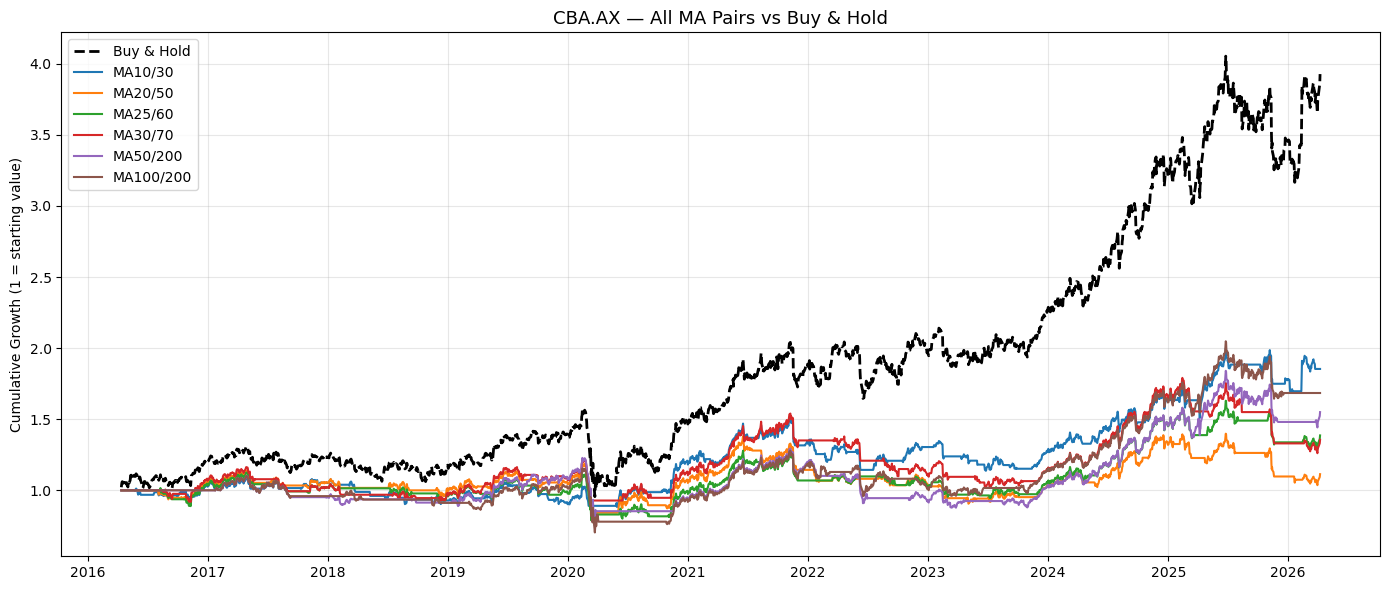

Saved: ma_all_pairs_CBA.AX.png



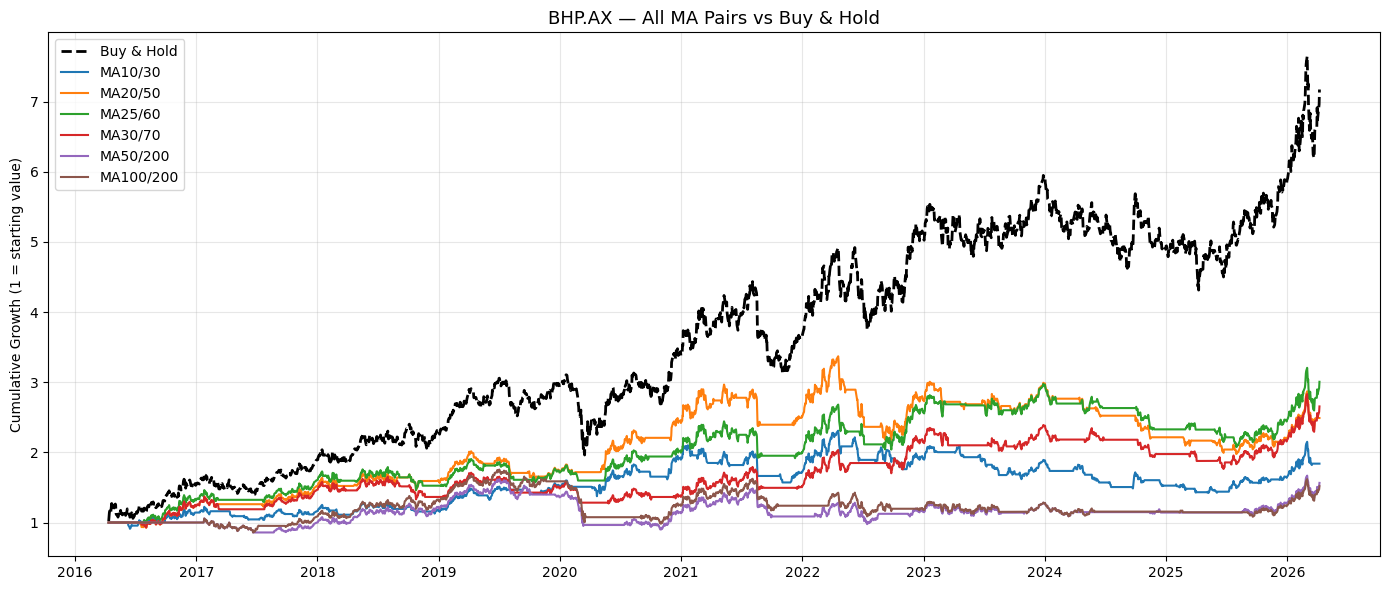

Saved: ma_all_pairs_BHP.AX.png



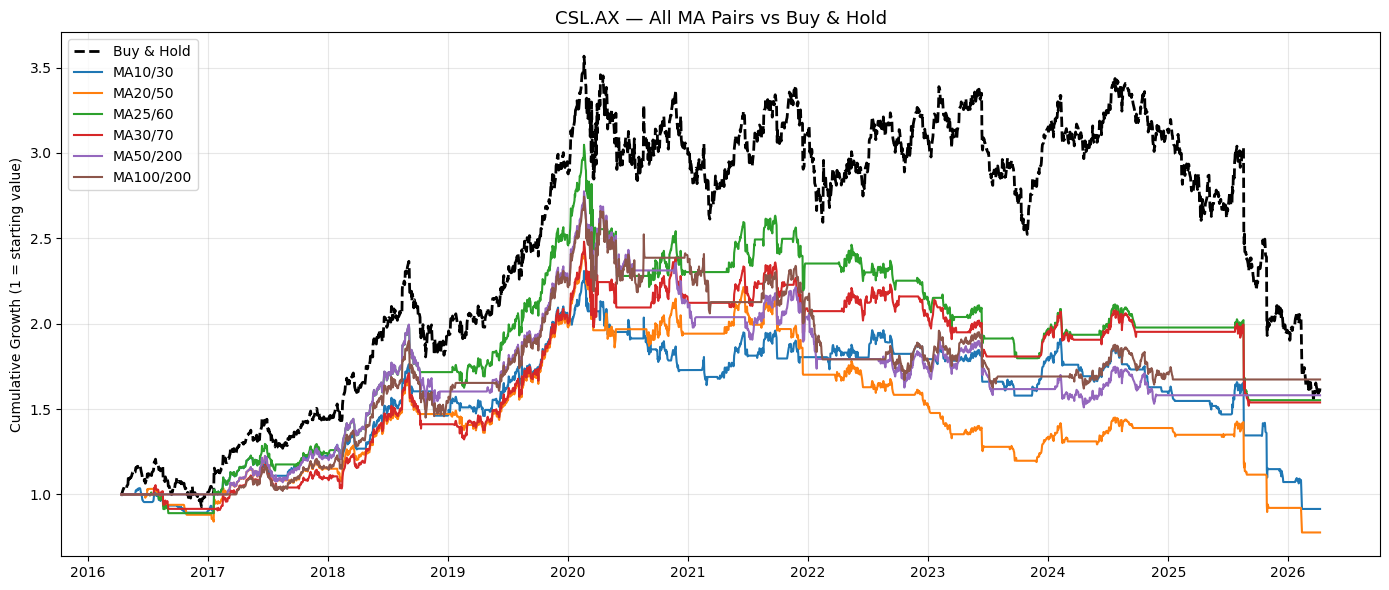

Saved: ma_all_pairs_CSL.AX.png



In [6]:
# ── All MA pairs overlaid per stock ───────────────────────────────────────────
# Shows every pair on one chart per stock so you can see which ones separated
for stock in stocks:
    sep = '=' * 65
    print(f"\n{sep}")
    print(f"  {stock} — All MA Pairs Compared")
    print(sep)
    print(results_df.loc[stock].to_string())

for stock in stocks:
    fig, ax = plt.subplots(figsize=(14, 6))

    # plot B&H once (same for all MA pairs)
    first_df = run_backtest(price_data[stock], *ma_pairs[0])
    ax.plot(first_df.index, first_df["cum_market"],
            color="black", linewidth=2, linestyle="--", label="Buy & Hold")

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    for (fast, slow), color in zip(ma_pairs, colors):
        df = run_backtest(price_data[stock], fast, slow)
        ax.plot(df.index, df["cum_strategy"],
                color=color, linewidth=1.5, label=f"MA{fast}/{slow}")

    ax.set_title(f"{stock} — All MA Pairs vs Buy & Hold", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("Cumulative Growth (1 = starting value)")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"ma_all_pairs_{stock}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: ma_all_pairs_{stock}.png\n")



  NVDA: 2580 rows
  CBA.AX: 2596 rows
  BHP.AX: 2596 rows

  In-sample  period: 2016-01-01 → 2021-01-01
  Out-of-sample period: 2021-01-01 → 2026-04-08

  STEP 1 — TRAINING (In-Sample: 2016-2020)
  Finding best MA pair per stock on training data only...
  NVDA: best in-sample pair = MA10/30 (Sharpe: 1.71)
  CBA.AX: best in-sample pair = MA10/30 (Sharpe: 0.19)
  BHP.AX: best in-sample pair = MA20/50 (Sharpe: 0.92)

Full in-sample results:
                  B&H Total Return %  Strat Total Return %  Strat Annual Return %  B&H Sharpe  Strat Sharpe  Strat Max DD %
Ticker MA Pair                                                                                                             
NVDA   MA10/30               1548.76               1000.32                  61.67        1.59          1.71          -34.04
       MA20/50               1548.76                916.49                  59.13        1.59          1.54          -37.55
       MA25/60               1548.76                887.97   

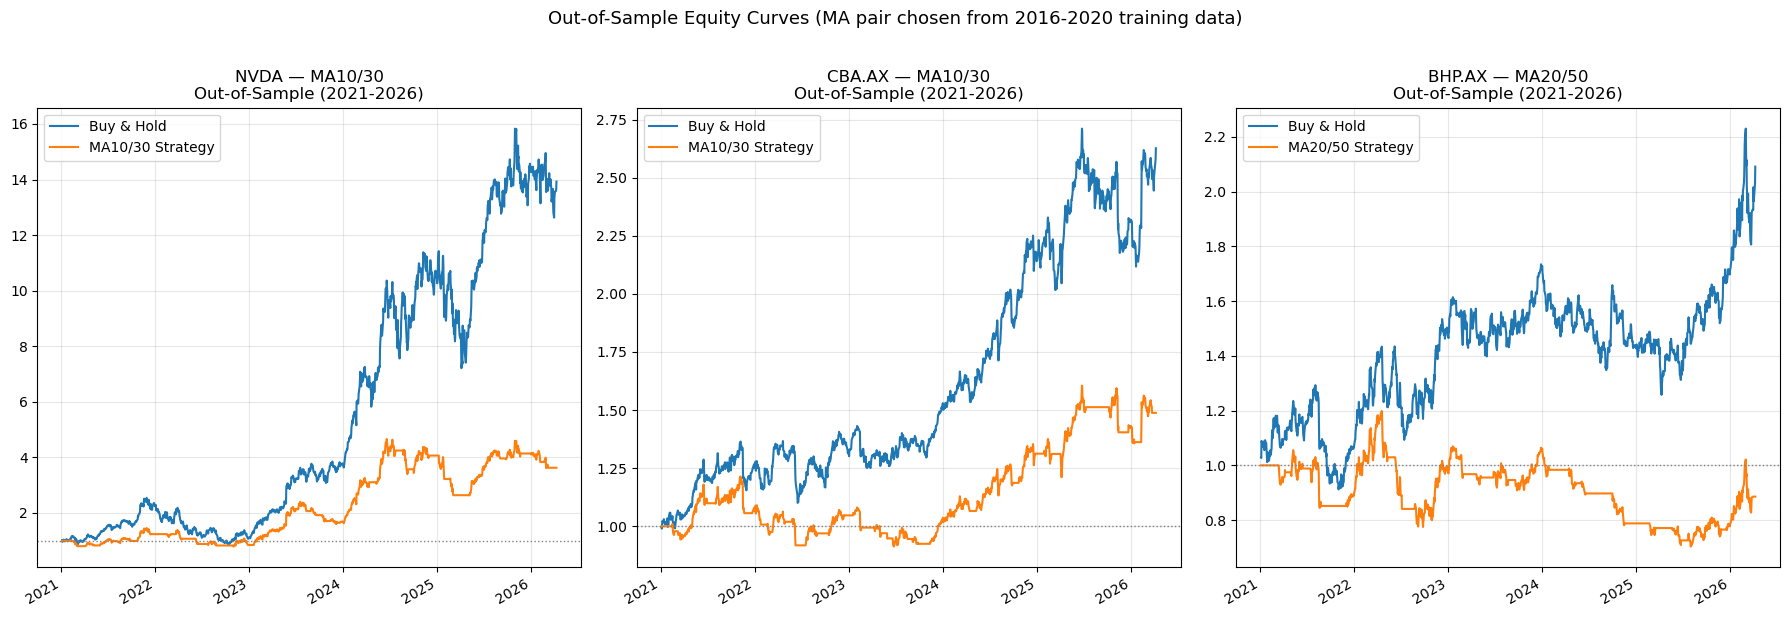


Chart saved as ma_out_of_sample_equity_curves.png


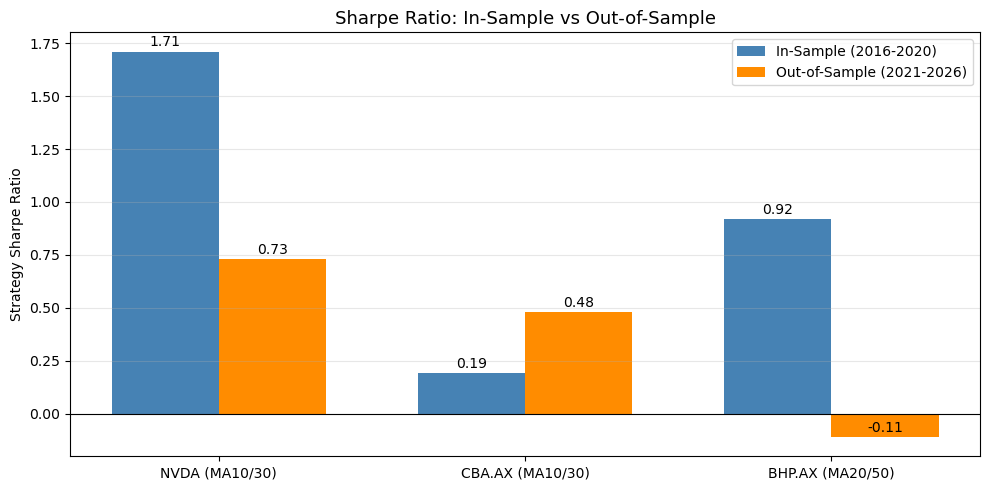

Chart saved as ma_sharpe_in_vs_out.png


In [7]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

# ── Configuration ──────────────────────────────────────────────────────────────
FULL_START = dt.datetime(2016, 1, 1)
SPLIT_DATE = dt.datetime(2021, 1, 1)   # train = before this, test = after this
FULL_END   = dt.datetime.now()

stocks   = ["NVDA", "CBA.AX", "BHP.AX"]
ma_pairs = [(10, 30), (20, 50), (25, 60), (30, 70), (50, 200), (100, 200)]

PERIODS_PER_YEAR = 252


# ── Helpers ────────────────────────────────────────────────────────────────────
def run_backtest(price_series, fast, slow):
    df = pd.DataFrame({"price": price_series})
    df[f"MA{fast}"] = df["price"].rolling(window=fast).mean()
    df[f"MA{slow}"] = df["price"].rolling(window=slow).mean()
    df["signal"]   = (df[f"MA{fast}"] > df[f"MA{slow}"]).astype(int)
    df["position"] = df["signal"].shift(1)
    df["log_returns"]          = np.log(df["price"] / df["price"].shift(1))
    df["strategy_log_returns"] = df["position"] * df["log_returns"]
    df["cum_market"]   = np.exp(df["log_returns"].cumsum())
    df["cum_strategy"] = np.exp(df["strategy_log_returns"].cumsum())
    return df

def max_drawdown(cum_series):
    running_max = cum_series.cummax()
    return ((cum_series - running_max) / running_max).min()

def get_metrics(df):
    market_lr   = df["log_returns"].dropna()
    strategy_lr = df["strategy_log_returns"].dropna()
    total_mkt    = df["cum_market"].dropna().iloc[-1]   - 1
    total_strat  = df["cum_strategy"].dropna().iloc[-1] - 1
    ann_mkt      = np.exp(market_lr.mean()   * PERIODS_PER_YEAR) - 1
    ann_strat    = np.exp(strategy_lr.mean() * PERIODS_PER_YEAR) - 1
    vol_mkt      = market_lr.std()   * np.sqrt(PERIODS_PER_YEAR)
    vol_strat    = strategy_lr.std() * np.sqrt(PERIODS_PER_YEAR)
    sharpe_mkt   = ann_mkt   / vol_mkt   if vol_mkt   != 0 else np.nan
    sharpe_strat = ann_strat / vol_strat if vol_strat != 0 else np.nan
    mdd_strat    = max_drawdown(df["cum_strategy"].dropna())
    return {
        "B&H Total Return %":    round(total_mkt   * 100, 2),
        "Strat Total Return %":  round(total_strat * 100, 2),
        "Strat Annual Return %": round(ann_strat   * 100, 2),
        "B&H Sharpe":            round(sharpe_mkt,   2),
        "Strat Sharpe":          round(sharpe_strat, 2),
        "Strat Max DD %":        round(mdd_strat   * 100, 2),
    }


# ── Step 1: Download full price data ──────────────────────────────────────────
print("Downloading data...\n")
price_data = {}
for stock in stocks:
    raw = yf.download(stock, start=FULL_START, end=FULL_END,
                      auto_adjust=True, progress=False)
    price_data[stock] = raw["Close"].squeeze()
    print(f"  {stock}: {len(raw)} rows")


# ── Step 2: Split into in-sample and out-of-sample ────────────────────────────
in_sample  = {s: price_data[s][price_data[s].index < SPLIT_DATE]  for s in stocks}
out_sample = {s: price_data[s][price_data[s].index >= SPLIT_DATE] for s in stocks}

print(f"\n  In-sample  period: {FULL_START.date()} → {SPLIT_DATE.date()}")
print(f"  Out-of-sample period: {SPLIT_DATE.date()} → {FULL_END.date()}\n")


# ── Step 3: Find best MA pair per stock using IN-SAMPLE data ONLY ─────────────
print("=" * 70)
print("  STEP 1 — TRAINING (In-Sample: 2016-2020)")
print("  Finding best MA pair per stock on training data only...")
print("=" * 70)

best_pairs        = {}
in_sample_results = []

for stock in stocks:
    best_sharpe = -999
    best_pair   = None
    for fast, slow in ma_pairs:
        df      = run_backtest(in_sample[stock], fast, slow)
        metrics = get_metrics(df)
        metrics["Ticker"]  = stock
        metrics["MA Pair"] = f"MA{fast}/{slow}"
        in_sample_results.append(metrics)
        if metrics["Strat Sharpe"] > best_sharpe:
            best_sharpe = metrics["Strat Sharpe"]
            best_pair   = (fast, slow)
    best_pairs[stock] = best_pair
    print(f"  {stock}: best in-sample pair = MA{best_pair[0]}/{best_pair[1]} "
          f"(Sharpe: {best_sharpe:.2f})")

in_sample_df = pd.DataFrame(in_sample_results).set_index(["Ticker", "MA Pair"])
print("\nFull in-sample results:")
print(in_sample_df.to_string())


# ── Step 4: Apply chosen pairs to OUT-OF-SAMPLE data ─────────────────────────
print("\n" + "=" * 70)
print("  STEP 2 — TESTING (Out-of-Sample: 2021-2026)")
print("  Applying pairs chosen from training data to unseen data...")
print("=" * 70)

oos_results = []
oos_data    = {}

for stock in stocks:
    fast, slow = best_pairs[stock]
    df         = run_backtest(out_sample[stock], fast, slow)
    metrics    = get_metrics(df)
    metrics["Ticker"]  = stock
    metrics["MA Pair"] = f"MA{fast}/{slow}"
    oos_results.append(metrics)
    oos_data[stock] = df
    print(f"\n  {stock} — MA{fast}/{slow} on out-of-sample data:")
    for k, v in metrics.items():
        if k not in ["Ticker", "MA Pair"]:
            print(f"    {k}: {v}")

oos_df = pd.DataFrame(oos_results).set_index("Ticker")


# ── Step 5: Side-by-side comparison table ─────────────────────────────────────
print("\n" + "=" * 70)
print("  IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON")
print("=" * 70)

rows = []
for stock in stocks:
    fast, slow  = best_pairs[stock]
    pair_label  = f"MA{fast}/{slow}"
    in_s  = in_sample_df.loc[(stock, pair_label)]
    out_s = oos_df.loc[stock]
    rows.append({
        "Ticker":             stock,
        "Best Pair":          pair_label,
        "IN Strat Return %":  in_s["Strat Total Return %"],
        "OUT Strat Return %": out_s["Strat Total Return %"],
        "IN B&H Return %":    in_s["B&H Total Return %"],
        "OUT B&H Return %":   out_s["B&H Total Return %"],
        "IN Sharpe":          in_s["Strat Sharpe"],
        "OUT Sharpe":         out_s["Strat Sharpe"],
        "IN Max DD %":        in_s["Strat Max DD %"],
        "OUT Max DD %":       out_s["Strat Max DD %"],
    })

comparison = pd.DataFrame(rows).set_index("Ticker")
print(comparison.to_string())

print("\n  VERDICT:")
for stock in stocks:
    in_sharpe  = comparison.loc[stock, "IN Sharpe"]
    out_sharpe = comparison.loc[stock, "OUT Sharpe"]
    drop       = ((out_sharpe - in_sharpe) / abs(in_sharpe)) * 100 if in_sharpe != 0 else float("nan")
    out_ret    = comparison.loc[stock, "OUT Strat Return %"]
    beats_bah  = out_ret > comparison.loc[stock, "OUT B&H Return %"]
    print(f"  {stock}: Sharpe {in_sharpe:.2f} -> {out_sharpe:.2f} "
          f"({drop:+.1f}%)  |  Beats B&H out-of-sample: {beats_bah}")


# ── Step 6: Out-of-sample equity curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, stock in enumerate(stocks):
    ax         = axes[i]
    fast, slow = best_pairs[stock]
    df         = oos_data[stock]

    df[["cum_market", "cum_strategy"]].plot(ax=ax)
    ax.set_title(f"{stock} — MA{fast}/{slow}\nOut-of-Sample (2021-2026)", fontsize=12)
    ax.legend(["Buy & Hold", f"MA{fast}/{slow} Strategy"])
    ax.set_xlabel("")
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1, color="gray", linestyle=":", linewidth=1)

plt.suptitle("Out-of-Sample Equity Curves (MA pair chosen from 2016-2020 training data)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("ma_out_of_sample_equity_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved as ma_out_of_sample_equity_curves.png")


# ── Step 7: In-sample vs Out-of-sample Sharpe bar chart ──────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 5))

x      = np.arange(len(stocks))
width  = 0.35
in_sh  = [comparison.loc[s, "IN Sharpe"]  for s in stocks]
out_sh = [comparison.loc[s, "OUT Sharpe"] for s in stocks]

bars1 = ax2.bar(x - width/2, in_sh,  width, label="In-Sample (2016-2020)",     color="steelblue")
bars2 = ax2.bar(x + width/2, out_sh, width, label="Out-of-Sample (2021-2026)", color="darkorange")

ax2.set_xticks(x)
labels = [s + ' (' + str(comparison.loc[s, 'Best Pair']) + ')' for s in stocks]
ax2.set_xticklabels(labels)
ax2.set_ylabel("Strategy Sharpe Ratio")
ax2.set_title("Sharpe Ratio: In-Sample vs Out-of-Sample", fontsize=13)
ax2.legend()
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.grid(True, alpha=0.3, axis="y")

for bar in bars1 + bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("ma_sharpe_in_vs_out.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as ma_sharpe_in_vs_out.png")
